# Проверка градиента

При нахождении частных производных нейросети несложно допустить ошибку.
Одновременно, в силу сложности алгоритма, даже в этом случае модель может
по-прежнему выдавать достаточно хороший результат.

Оценить правильность расчета частных производных можно с помощью метода
проверки градиента (gradient checking).

## Основная идея

Основная идея заключается в том, что $(1)$ значение градиента, рассчитанное
нейросетью в процессе обратного распространения ошибки при некоторых весах
$\theta,$ должно примерно соответствовать $(2)$ его численной оценке в этой
точке.

$$ \nabla J (\theta) \approx \frac{J(\theta + \varepsilon)-J(\theta-\varepsilon)}{2
\varepsilon} $$

Начнем разбирать это выражение.
## Значение градиента
Первый компонент, значение градиента, найти не сложно:
* необходимо задать некоторые веса $\theta;$
* рассчитать уровень ошибки через прямое распространение; и
* найти производные относительно каждого $\theta$ всех слоев нейросети.

Другими словами выполнить одну эпоху обучения нейросети, но только не
обновлять веса $\theta,$ а ограничиться расчетом градиента.

$$ \theta_j := \theta_j-\alpha {\color{Orange} \nabla J (\theta) } $$

## Численная оценка градиента

Второй компонент, численная оценка градиента, есть не что иное, как значение
градиента, рассчитанное через отношение приращений.

![](https://drive.google.com/uc?export=view&id=1ziREr-q3UE4RSHWGU1kJ2q-tr_aOByyk)

Вспомним, что при стремлении $\Delta w$ к нулю, мы получим точное значение
производной в точке $w.$

$$ f'(w) = \lim\limits_{\Delta w \to 0} \frac {f(w+\Delta w)-f(w)}{\Delta w} $$

Конечно, компьютер не позволит нам бесконечно уменьшать значение $\Delta w$,
однако мы можем положить это значение очень малым, и тогда численная (то есть
найденная с помощью компьютера) оценка должна быть примерно равна значению
производной.

$$ f'(w) \approx \frac {f(w+\Delta w)-f(w)}{\Delta w} $$

Заменим $\Delta w$ на $\varepsilon$, а $w$ на $\theta$ для сохранения
предложенной выше нотации. Кроме того, будем брать точку для расчета секущей
линии не с одной стороны (one-sided) от параметра, а с двух (two-sided) на
расстоянии $\pm \varepsilon$ от $\theta.$
![](https://drive.google.com/uc?export=view&id=12CZveSjrYEP5N8eOvt_7R3jiPzZtZuLc)

Так мы получим,

$$ f'(\theta) \approx \frac{f(\theta + \varepsilon)-f(\theta-\varepsilon)}{2 \varepsilon} $$

Если выданное нейросетью значение градиента совпадет в пределах некоторого
небольшого порога с его численной оценкой, значит обратное распространение
работает правильно.

# Простые примеры
## Один параметр
Вначале приведем простой пример с одним параметром. Рассмотрим следующую
функцию потерь.

$$ f(\theta) = \theta^2 $$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score

In [2]:
def f(theta):
  return theta ** 2

Производная этой функции равна $ f'(\theta) = 2 \theta .$

In [3]:
def derivative(theta):
  return 2 * theta

Положим $ \theta = 3 $ и найдем значение производной в этой точке.
$$ f'(3) = 2 \cdot 3 = 6 $$

In [7]:
theta = 3
deriv = derivative(3)
deriv

6

Это первый компонент. Теперь выполним численную оценку производной в этой
же точке, положив $\varepsilon = 1\mathrm{e}{-7}.$

$$ f’_{\text{numeric}} = \frac{f(\theta + \varepsilon)-f(\theta-\varepsilon)}{2
\varepsilon} = $$

$$ \frac{f(3 + 1\mathrm{e}{-7})-f(3-1\mathrm{e}{-7})}{2 \cdot 1\mathrm{e}{-7}}
\approx 5{,}999999 $$

In [8]:
eps = 1e-7

In [9]:
derivNumeric = (f(theta + eps) - f(theta - eps)) / (2 * eps)
derivNumeric

5.999999990180527

Если разница между значением производной и ее численной оценкой меньше, чем $
\varepsilon,$ то можно считать, что производная взята верно.

In [10]:
deriv - derivNumeric, deriv - derivNumeric < eps

(9.819473234529141e-09, True)

### Два параметра

Рассмотрим функцию потерь с двумя параметрами

$$ f(\theta_1, \theta_2) = \theta_1^2 + \theta_2^2 $$

In [11]:
def f(theta1, theta2):
  return theta1 ** 2 + theta2 ** 2

и соответствующими частными производными

$$ \frac{ \partial }{ \partial \theta_1 } f( \theta_1, \theta_2 ) = 2 \theta_1, \quad \frac{
\partial }{ \partial \theta_2 } f( \theta_1, \theta_2 ) = 2 \theta_2 $$

In [12]:
def partial1(theta1):
  return 2 * theta1

In [13]:
def partial2(theta2):
  return 2 * theta2

Найдем значение градиента в точке $(3, 4).$

$$ \nabla f( 3, 4 ) = \begin{bmatrix} \frac{ \partial }{ \partial \theta_1 } \\ \frac{ \partial
}{ \partial \theta_1 } \end{bmatrix} f( 3, 4 ) = \begin{bmatrix} 2 \cdot 3 \\ 2 \cdot 4
\end{bmatrix} = \begin{bmatrix} 6 \\ 8 \end{bmatrix} $$

In [14]:
theta1, theta2 = 3, 4
grad = np.array([partial2(theta1), partial2(theta2)])
grad

array([6, 8])

Численную оценку при этом будем проводить, находя отношение приращений
отдельно по каждому измерению

$$ \frac{ \partial }{ \partial \theta_1 } f( \theta_1, \theta_2 ) \approx \frac{ f( \theta_1 +
\varepsilon, \theta_2 )-(\theta_1-\varepsilon, \theta_2) }{ 2\varepsilon } $$

$$ \frac{ \partial }{ \partial \theta_2 } f( \theta_1, \theta_2 ) \approx \frac{ f( \theta_1,
\theta_2 + \varepsilon )-(\theta_1, \theta_2-\varepsilon ) }{ 2\varepsilon } $$

In [15]:
partial1Numeric = (f(theta1 + eps, theta2) - f(theta1 - eps, theta2)) / (2 * eps)
partial2Numeric = (f(theta1, theta2 + eps) - f(theta1, theta2 - eps)) / (2 * eps)

gradNumeric = np.array([partial1Numeric, partial2Numeric])
gradNumeric

array([5.99999998, 8.        ])

Оценим разницу между значением градиента и его численной оценкой по формуле

$$ \text{difference} = \frac{ || \nabla f(\theta)_{\text{numeric}}-\nabla f(\theta) ||_2 }{ ||
\nabla f(\theta)_{\text{numeric}} ||_2+|| \nabla f(\theta) ||_2} $$

В числителе мы находим евклидово расстояние разницы между фактическим
градиентом и его численной оценкой, а в знаменателе нормализуем эту разницу на
сумму длин соответствующих векторов.

In [16]:
numerator = np.linalg.norm(grad - gradNumeric)
denominator = np.linalg.norm(grad) + np.linalg.norm(gradNumeric)
difference = numerator / denominator
difference, difference < eps

(np.float64(9.637876920383396e-10), np.True_)

Перейдем к проверке частных производных нейросети.

## Проверка градиента нейросети

Для проверки градиента нейросети необходимо сравнить фактическое значение
частной производной каждого из $\theta_j$ параметров с соответствующей
численной оценкой.

$$ \begin{array}{cc} \frac{ \partial }{ \partial \theta_1 } J(\theta) & \approx & \frac{ J(
\theta_1 + \varepsilon, \theta_2, \theta_3, \ldots, \theta_j )-J(\theta_1-\varepsilon, \theta_2,
\theta_3, \ldots, \theta_j ) }{ 2\varepsilon } \\ \frac{ \partial }{ \partial \theta_2 } J(\theta)
& \approx & \frac{ J( \theta_1, \theta_2 + \varepsilon, \theta_3, \ldots, \theta_j )-
J(\theta_1, \theta_2-\varepsilon, \theta_3, \ldots, \theta_j ) }{ 2\varepsilon } \\ \frac{
\partial }{ \partial \theta_3 } J(\theta) & \approx & \frac{ J( \theta_1, \theta_2, \theta_3 +
\varepsilon, \ldots, \theta_j )-J(\theta_1, \theta_2, \theta_3-\varepsilon, \ldots, \theta_j ) }{
2\varepsilon } \\ \ldots & & \ldots \\ \frac{ \partial }{ \partial \theta_j } J(\theta) & \approx
& \frac{ J( \theta_1, \theta_2, \theta_3, \ldots, \theta_j + \varepsilon )-J(\theta_1, \theta_2,
\theta_3, \ldots, \theta_j-\varepsilon ) }{ 2 \varepsilon } \end{array} $$

Технически нам нужно будет сформировать два вектора, $ \nabla J(\theta) $ и $
\nabla_{\text{numeric}} J(\theta) $ и сравнить их через нормализованное евклидово
расстояние.

### Подготовка данных

В первую очередь подготовим данные. Возьмем небольшой датасет о вине из
библиотеки sklearn, поскольку проверка градиета является вычислительно
затратной операцией и, например, на данных MNIST будет выполняться очень
долго.

In [17]:
# возьмем функцию для one-hot encoding
def ohe(y):
  examples, features = y.shape[0], len(np.unique(y))
  zeros_matrix = np.zeros((examples, features))
  for i, (row, digit) in enumerate(zip(zeros_matrix, y)):
    zeros_matrix[i][digit] = 1

  return zeros_matrix

In [18]:
# подгрузим данные
data = load_wine()

# сформируем две матрицы Numpy, в которых наблюдения будут столбцами
X = pd.DataFrame(data.data, columns = data.feature_names)
X = ((X - X.mean())/X.std()).values.T
y = data.target
y_enc = ohe(y).T

X.shape, y_enc.shape

((13, 178), (3, 178))

Как мы видим, у нас будет 13 признаков, 178 наблюдений и 3 класса целевой
переменной.

## Архитектура сети
Проверим градиент нейросети, которую мы создали в конце основного занятия с
тем отличием, что
* мы уменьшим количество нейронов входного слоя до 13-ти (вместо 784
пикселей картинок MNIST);
* выходной слой будет состоять из трех нейронов по числу классов целевой
переменной;
* два скрытых слоя будут содержать не 64, а 16 нейронов.

При этом функции активации (сигмоиду и softmax), а также функция потерь
(категориальная кросс-энтропия) сохранятся и в текущей архитектуре. Кроме этого,
сохраним смещение.

![](https://drive.google.com/uc?export=view&id=1F3Vtoi4TN2vi9tmnGCD_pxIxR5N6JySV)

Примечание. Обратите внимание, по сравнению с предыдущими архитектурами,
мы перестали называть входящий слой (данные) $A^{(1)}$ и просто сохраним
обозначение X (подобную замену мы делали для единообразия нотации и
наглядности).


In [19]:
# в частности в коде исчезла вот эта строчка
A1 = X

Таким образом, индексы активационных слоев сместятся на один вперед.

В результате предложенных изменений частные производные останутся прежними.
Сократится лишь количество весов. Если в архитектуре нейросети для MNIST у нас
было

$$ \underbrace { 64 \cdot 784 }_{W^{(1)}} + \underbrace { 64 \cdot 1 }_{b^{(1)}} +
\underbrace { 64 \cdot 64 }_{W^{(2)}} + \underbrace { 64 \cdot 1 }_{b^{(2)}} +
\underbrace { 10 \cdot 64 }_{W^{(3)}} + \underbrace { 10 \cdot 1 }_{b^{(3)}} = 55050
$$

параметров, то благодаря предложенным изменениям их останется только

$$ 16 \cdot 13 + 16 \cdot 1 + 16 \cdot 16 + 16 \cdot 1 + 3 \cdot 16 + 3 \cdot 1 = 547 $$

Это существенно ускорит выполнение кода.

### Необходимые функции

Объявим необходимые для данной архитектуры функции.
### Служебные функции
Начнем с функций активации, а также целевой функции.

In [20]:
def sigmoid(z):
  s = 1 / (1 + np.exp(-z))
  return s

def softmax(z):
  z = z - np.max(z, axis = 0, keepdims = True)
  numerator = np.exp(z)
  denominator = np.sum(numerator, axis = 0, keepdims = True)
  softmax = numerator / denominator
  return softmax

def cross_entropy(probs, y_enc, epsilon = 1e-9):
  n = probs.shape[1]
  ce = -np.sum(y_enc * np.log(probs + epsilon)) / n

  return ce

Кроме этого, поместим в отдельные функции код
* инициализации параметров;
* прямого; и
* обратного распространения.

### Инициализация параметров

Функция инициализации параметров на вход примет данные и точку отсчета для
повторимости результата, а на выходе выдаст словарь из весов $W^{(1)}, W^{(2)},
W^{(3)}$ и смещений $b^{(1)}, b^{(2)}, b^{(3)}.$

In [21]:
def initialize(x, y, random_state = 42):

  np.random.seed(random_state)

  parameters = {}

  parameters['W1'] = np.random.randn(16, x.shape[0])
  parameters['b1'] = np.zeros((16, 1))

  parameters['W2'] = np.random.randn(16, 16)
  parameters['b2'] = np.zeros((16, 1))

  parameters['W3'] = np.random.randn(y.shape[0], 16)
  parameters['b3'] = np.zeros((y.shape[0], 1))

  return parameters

### Прямое и обратное распространение
После этого,
* функция прямого распространения один раз получит случайные начальные
параметры от функции инициализации; а затем
* в цикле:
  * будет взаимодействовать с функцией обратного распространения через
кортеж параметров и значений активационных функций cache;
  * функция же обратного распространения будет выдавать словарь
обновленных параметров, которые станут новыми входными данными
прямого распространения на следующей эпохе.

Дополнительно, функция прямого распространения будет выдавать уровень
ошибки, а обратного — словарь со значениями текущих частных производных
$\frac{ \partial J}{ \partial W^{(1)} }, \frac{ \partial J}{ \partial W^{(2)} }, \frac{ \partial
J}{ \partial W^{(3)} }$ и $\frac{ \partial J}{ \partial b^{(1)} }, \frac{ \partial J}{ \partial
b^{(2)} }, \frac{ \partial J}{ \partial b^{(3)} }.$ Они понадобятся для выполнения
проверки градиента.

![](https://drive.google.com/uc?export=view&id=1e-1qB9bH_5ErzI5qtAwVnfubKZAHFMCG)


In [22]:
def forward(x, y, parameters):

  n = x.shape[1]

  W1 = parameters['W1']
  b1 = parameters['b1']
  W2 = parameters['W2']
  b2 = parameters['b2']
  W3 = parameters['W3']
  b3 = parameters['b3']

  Z1 = np.dot(W1, x) + b1
  A1 = sigmoid(Z1)

  Z2 = np.dot(W2, A1) + b2
  A2 = sigmoid(Z2)

  Z3 = np.dot(W3, A2) + b3
  A3 = softmax(Z3)

  loss = cross_entropy(A3, y)

  cache = (A1, W1, b1, A2, W2, b2, A3, W3, b3)

  return loss, cache

In [23]:
def backward(x, y, cache, lr = 0.1):

  (A1, W1, b1, A2, W2, b2, A3, W3, b3) = cache

  n = x.shape[1]

  W3_delta = A3 - y
  W2_delta = np.dot(W3.T, W3_delta) * A2 * (1 - A2)
  W1_delta = np.dot(W2.T, W2_delta) * A1 * (1 - A1)

  W3_derivative = np.dot(W3_delta, A2.T) / n
  b3_derivative = np.sum(W3_delta, axis = 1, keepdims = True) / n

  W2_derivative = np.dot(W2_delta, A1.T) / n
  b2_derivative = np.sum(W2_delta, axis = 1, keepdims = True) / n

  W1_derivative = np.dot(W1_delta, x.T) / n
  b1_derivative = np.sum(W1_delta, axis = 1, keepdims = True) / n

  parameters = {}

  parameters['W3'] = W3 - lr * W3_derivative
  parameters['b3'] = b3 - lr * b3_derivative
  parameters['W2'] = W2 - lr * W2_derivative
  parameters['b2'] = b2 - lr * b2_derivative
  parameters['W1'] = W1 - lr * W1_derivative
  parameters['b1'] = b1 - lr * b1_derivative

  gradients = {}

  gradients['dW3'] = W3_derivative
  gradients['db3'] = b3_derivative
  gradients['dW2'] = W2_derivative
  gradients['db2'] = b2_derivative
  gradients['dW1'] = W1_derivative
  gradients['db1'] = b1_derivative

  return parameters, gradients

### Обучение и прогноз
Обучим модель, сделаем прогноз (пока без проверки градиента) и оценим его
качество.

In [24]:
def fit_nn(x, y, epochs = 1000, lr = 0.1):

  parameters = initialize(x, y)
  loss_history = []

  for i in range(epochs):

    loss, cache = forward(x, y, parameters)
    # функция backward() выдает два словаря: parameters и gradients
    # словарь gradients пока не нужен, и мы оставляем _
    parameters, _ = backward(x, y, cache, lr)

    if i % (epochs / 5) == 0:
      print('Эпоха:', i)
      print('Ошибка:', loss)
      print('-----------------------')

    loss_history.append(loss)

  print('Итоговая ошибка', loss)
  print('Нейросеть успешно обучена')

  return parameters, loss_history

In [25]:
def predict_nn(x, y, parameters):

  W1 = parameters['W1']
  b1 = parameters['b1']
  W2 = parameters['W2']
  b2 = parameters['b2']
  W3 = parameters['W3']
  b3 = parameters['b3']

  Z1 = np.dot(W1, x) + b1
  A1 = sigmoid(Z1)
  Z2 = np.dot(W2, A1) + b2
  A2 = sigmoid(Z2)
  Z3 = np.dot(W3, A2) + b3
  A3 = softmax(Z3)

  return np.argmax(A3, axis = 0)

In [26]:
params, l_history = fit_nn(X, y_enc, epochs = 2000, lr = 0.05)

Эпоха: 0
Ошибка: 2.509097471743286
-----------------------
Эпоха: 400
Ошибка: 0.10235096802330654
-----------------------
Эпоха: 800
Ошибка: 0.05057850069287952
-----------------------
Эпоха: 1200
Ошибка: 0.03258876982290582
-----------------------
Эпоха: 1600
Ошибка: 0.02361639562547594
-----------------------
Итоговая ошибка 0.018294002509190735
Нейросеть успешно обучена


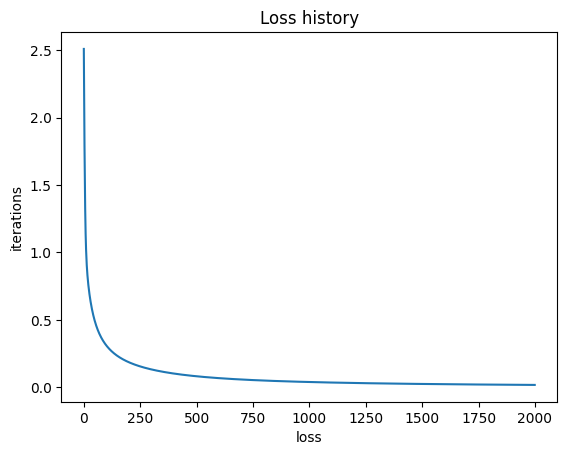

In [27]:
plt.plot(l_history)
plt.title('Loss history')
plt.xlabel('loss')
plt.ylabel('iterations');

In [28]:
y_pred = predict_nn(X, y_enc, params)
accuracy_score(y, y_pred)

1.0

Перейдем к проверке градиента этой нейросети.

### Проверка градиента после инициализации

Вначале сравним фактические градиенты с их численной оценкой сразу после
инициализации параметров. Для этого сделаем следующее:
1. инициализируем параметры и поместим их в словарь;
2. найдем фактические значения градиентов при этих параметрах,
  * получив их из функции обратного распространения; и
  * преобразовав словарь в длинный вектор из 547 градиентов;
3. выполним численную оценку градиента для каждого из параметров, для чего
  * сформируем вектор из 547 параметров;
  * в цикле пройдемся по каждому из этих параметров и численно оценим
соответствующую частную производную через $ \frac{ J( \theta_j +
\varepsilon )-J(\theta_j-\varepsilon ) }{ 2 \varepsilon } ;$ и
  * сформируем вектор из 547 численных оценок градиентов; наконец
4. сравним фактические градиенты с их численной оценкой через
нормализованное евклидово расстояние.

### Переход от словаря к вектору и обратно

### **Словарь градиентов в вектор**
Во втором пункте приведенной выше последовательности шагов нам нужно
преобразовать словарь с ключами dW1, db1, dW2, db2, dW3, db3 в вектор
размерностью (547, 1).
![](https://drive.google.com/uc?export=view&id=1TyhE7c3DxuWE1qVV7n4BGeJMfRaf9F0b)

Для этого, в цикле пройдемся по ключам словаря градиентов, «вытянем»
соответствующие матрицы значений и соединим их через **функцию np.concatenate()**.

In [30]:
# на вход функция примет словарь градиентов и
def gradients_to_vector(gradients):

  # создаст массив из "вытянутых" значений словаря
  return np.concatenate([np.reshape(gradients[key], (-1,1)) for key in ['dW1', 'db1', 'dW2', 'db2', 'dW3', 'db3']])

### Словарь параметров в вектор
Третий пункт предполагает, что мы аналогичным образом преобразуем словарь
параметров в вектор.
![](https://drive.google.com/uc?export=view&id=1X1osuB-q7RA7rfL9zAJL8jGpG340oxG_)



In [31]:
def dictionary_to_vector(parameters):
  return np.concatenate([np.reshape(parameters[key], (-1,1)) for key in ['W1', 'b1', 'W2', 'b2', 'W3', 'b3']])

### Вектор параметров в словарь
Наконец в том же третьем пункте для того, чтобы рассчитать $ J( \theta_j +
\varepsilon ) $ и $ J(\theta_j-\varepsilon ) $ нам необходимо поместить в словарь
векторы $\theta_j + \varepsilon$ и $\theta_j + \varepsilon$ размерностью (547, 1)
перед их «отправкой» в функцию прямого распространения.

![](https://drive.google.com/uc?export=view&id=1dlA3C0dqUkyFWdBYaLXD5ESfazFPHeUM)


In [32]:
def vector_to_dictionary(theta):

  parameters = {}

  parameters['W1'] = theta[:208].reshape((16,13))
  parameters['b1'] = theta[208:224].reshape((16,1))
  parameters['W2'] = theta[224:480].reshape((16,16))
  parameters['b2'] = theta[480:496].reshape((16,1))
  parameters['W3'] = theta[496:544].reshape((3,16))
  parameters['b3'] = theta[544:547].reshape((3,1))

  return parameters

***Примечание***. Мы могли бы автоматизировать расчет индексов, однако в учебных
целях пропишем индексы каждого из параметров вручную.
Перейдем непосредственно к проверке градиента.

#### Инициализация параметров

Выполним инициализацию параметров.

In [33]:
parameters = initialize(X, y_enc, random_state = 42)

#### Значение градиента

Найдем фактические значения градиентов при инициализированных параметрах и
поместим их в вектор.

In [34]:
_, cache = forward(X, y_enc, parameters)
_, gradients = backward(X, y_enc, cache)

grad = gradients_to_vector(gradients)
grad.shape

(547, 1)

#### Численная оценка градиента
Выполним численную оценку градиентов. Преобразуем словарь параметров в
вектор.

In [35]:
parameters_values = dictionary_to_vector(parameters)
parameters_values.shape

(547, 1)

Сохраним количество параметров, а также создадим нулевые векторы для $ J(
\theta_j + \varepsilon ), $ $ J(\theta_j-\varepsilon ) $ и $\nabla_{\text{numeric}}
J(\theta).$ Не забудем про константу $\varepsilon.$

In [36]:
num_parameters = parameters_values.shape[0]

J_plus = np.zeros((num_parameters, 1))
J_minus = np.zeros((num_parameters, 1))

gradNumeric = np.zeros((num_parameters, 1))

epsilon = 1e-7

В цикле пройдем по каждому из 547 параметров и для каждого найдем численную
оценку производной.

$$ \begin{array}{cc} \frac{ J( \theta_1 + \varepsilon, \theta_2, \theta_3, \ldots,
\theta_{547} )-J(\theta_1-\varepsilon, \theta_2, \theta_3, \ldots, \theta_{547} ) }{
2\varepsilon } \\ \frac{ J( \theta_1, \theta_2 + \varepsilon, \theta_3, \ldots, \theta_{547} )-
J(\theta_1, \theta_2-\varepsilon, \theta_3, \ldots, \theta_{547} ) }{ 2\varepsilon } \\ \frac{
J( \theta_1, \theta_2, \theta_3 + \varepsilon, \ldots, \theta_{547} )-J(\theta_1, \theta_2,
\theta_3-\varepsilon, \ldots, \theta_{547} ) }{ 2\varepsilon } \\ \ldots & \\ \frac{ J(
\theta_1, \theta_2, \theta_3, \ldots, \theta_{547} + \varepsilon )-J(\theta_1, \theta_2,
\theta_3, \ldots, \theta_{547}-\varepsilon ) }{ 2 \varepsilon } \end{array} $$

In [37]:
# будем брать по одному параметру j
for j in range(num_parameters):

  thetaplus = np.copy(parameters_values)
  # добавим epsilon к параметру j
  thetaplus[j][0] = thetaplus[j][0] + epsilon
  # найдем значение целевой функции J(theta) с учетом theta_j + epsilon
  J_plus[j], _ = forward(X, y_enc, vector_to_dictionary(thetaplus))

  thetaminus = np.copy(parameters_values)
  # вычтем epsilon из параметра j
  thetaminus[j][0] = thetaminus[j][0] - epsilon
  # найдем значение целевой функции J(theta) с учетом theta_j - epsilon
  J_minus[j], _ = forward(X, y_enc, vector_to_dictionary(thetaminus))

  # оценим частную производную для данного параметра j
  gradNumeric[j] = (J_plus[j] - J_minus[j]) / (2 * epsilon)

In [38]:
gradNumeric.shape

(547, 1)

#### Сравнение градиента с его численной оценкой
Осталось сравнить фактическое значение градиента с его численной оценкой.

In [39]:
numerator = np.linalg.norm(grad - gradNumeric)
denominator = np.linalg.norm(grad) + np.linalg.norm(gradNumeric)
difference = numerator / denominator
difference, difference < epsilon

(np.float64(3.857216283210745e-08), np.True_)

Поместим приведенный выше код проверки градиента в функции.

In [40]:
def gradient_vector(parameters, x, y):

  _, cache = forward(x, y, parameters)
  _, gradients = backward(x, y, cache)

  return gradients_to_vector(gradients)

In [41]:
def gradNumeric_vector(parameters, x, y, epsilon):

  parameters_values = dictionary_to_vector(parameters)
  num_parameters = parameters_values.shape[0]

  J_plus = np.zeros((num_parameters, 1))
  J_minus = np.zeros((num_parameters, 1))

  gradNumeric = np.zeros((num_parameters, 1))

  for j in range(num_parameters):

    thetaplus = np.copy(parameters_values)
    thetaplus[j][0] = thetaplus[j][0] + epsilon
    J_plus[j], _ = forward(X, y_enc, vector_to_dictionary(thetaplus))

    thetaminus = np.copy(parameters_values)
    thetaminus[j][0] = thetaminus[j][0] - epsilon
    J_minus[j], _ = forward(X, y_enc, vector_to_dictionary(thetaminus))

    gradNumeric[j] = (J_plus[j] - J_minus[j]) / (2 * epsilon)

  return gradNumeric

In [42]:
def difference(grad, gradNumeric):

  numerator = np.linalg.norm(grad - gradNumeric)
  denominator = np.linalg.norm(grad) + np.linalg.norm(gradNumeric)

  return numerator / denominator

In [43]:
def gradient_checking(x, y, random_state, epsilon = 1e-7):

  params = initialize(x, y, random_state)

  grad = gradient_vector(params, x, y)
  gradNumeric = gradNumeric_vector(params, x, y, epsilon)

  diff = difference(grad, gradNumeric)

  return diff, diff < epsilon

In [44]:
gradient_checking(X, y_enc, random_state = 42)

(np.float64(3.857216283210745e-08), np.True_)

### Проверка градиента при обучении

Убедимся, что значение градиента совпадает с его численной оценкой не только
при начальных весах, но и в целом в процессе обучения нейросети.

In [45]:
def fit_nn_with_gradcheck(x, y, epochs = 2000, lr = 0.05,
                          random_state = 42, epsilon = 1e-7):

  # инициализируем параметры
  parameters = initialize(x, y, random_state)

  # в цикле
  for i in range(epochs):

    # сохраним текущие параметры (для проверки градиента)
    current_parameters = parameters.copy()

    # выполним прямое и
    loss, cache = forward(x, y, parameters)
    # обратное распространение, получив градиенты, а также
    # обновленные параметры (для дальнейшего обучения)
    parameters, gradients = backward(x, y, cache, lr)

    # периодически
    if i % (epochs / 5) == 0:
      print('Эпоха:', i)
      print('Ошибка:', loss)

      # создадим вектор градиентов, а также
      grad = gradients_to_vector(gradients)
      # вектор численной оценки градиентов на основе текущих параметров,
      gradNumeric = gradNumeric_vector(current_parameters, x, y, epsilon)
      # сравним эти векторы
      diff = difference(grad, gradNumeric)
      # и выведем результат сравнения
      print('Отклонение градиента:', diff)
      print('Проверка градиента пройдена:', diff < epsilon)
      print('-----------------------')

  print('Итоговая ошибка', loss)
  print('Нейросеть успешно обучена')

  return None

In [46]:
fit_nn_with_gradcheck(X, y_enc)

Эпоха: 0
Ошибка: 2.509097471743286
Отклонение градиента: 3.857216283210745e-08
Проверка градиента пройдена: True
-----------------------
Эпоха: 400
Ошибка: 0.10235096802330654
Отклонение градиента: 1.4535907633893824e-08
Проверка градиента пройдена: True
-----------------------
Эпоха: 800
Ошибка: 0.05057850069287952
Отклонение градиента: 1.9198821319434565e-08
Проверка градиента пройдена: True
-----------------------
Эпоха: 1200
Ошибка: 0.03258876982290582
Отклонение градиента: 2.4973202882258943e-08
Проверка градиента пройдена: True
-----------------------
Эпоха: 1600
Ошибка: 0.02361639562547594
Отклонение градиента: 3.1831681824535624e-08
Проверка градиента пройдена: True
-----------------------
Итоговая ошибка 0.018294002509190735
Нейросеть успешно обучена


Проверки пройдены успешно.